# VinoLens - Phase 2: Baseline Machine Learning Model (Linear Regression)

Now that we understand the wine dataset from Phase 1, we will train our very first predictive model.

### Roadmap for this Notebook:
1. **Feature Matrix (X) and Target Vector (y)**: Separate inputs from what we want to predict.
2. **Train/Test Split**: Split data into 80% training and 20% testing to evaluate on unseen data.
3. **Feature Scaling**: Standardize features to avoid bias from varying scales.
4. **Train Linear Regression**: Fit our first mathematical model.
5. **Evaluate Model Performance**: Measure MAE, MSE, RMSE, and R-squared.
6. **Inspect Coefficients**: Understand the weights the model assigned to each wine chemical.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the cleaned dataset
DATA_PATH = '../../data/raw/WineQT.csv'
df = pd.read_csv(DATA_PATH)

# Drop Id column if present
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# 2. Separate Features (X) and Target (y)
X = df.drop(columns=['quality'])
y = df['quality']

print(f'Feature matrix X shape: {X.shape} (11 chemical inputs)')
print(f'Target vector y shape: {y.shape} (quality scores)')
X.head()

Feature matrix X shape: (1143, 11) (11 chemical inputs)
Target vector y shape: (1143,) (quality scores)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [3]:
# 1. Perform 80/20 Train/Test Split
# random_state=42 ensures the split is reproducible every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: {X_train.shape[0]} wines (80%)")
print(f"Testing set:  {X_test.shape[0]} wines (20%)")
print("-" * 50)

# 2. Export both train and test splits to data/processed/
train_dataset = pd.concat([X_train, y_train], axis=1)
test_dataset = pd.concat([X_test, y_test], axis=1)

train_export_path = "../../data/processed/train_wine_samples.csv"
test_export_path = "../../data/processed/test_wine_samples.csv"

train_dataset.to_csv(train_export_path, index=False)
test_dataset.to_csv(test_export_path, index=False)

print(f"Successfully saved {len(train_dataset)} training wines to: {train_export_path}")
print(f"Successfully saved {len(test_dataset)} testing wines to:  {test_export_path}")

Training set: 914 wines (80%)
Testing set:  229 wines (20%)
--------------------------------------------------
Successfully saved 914 training wines to: ../../data/processed/train_wine_samples.csv
Successfully saved 229 testing wines to:  ../../data/processed/test_wine_samples.csv


In [5]:
# --- STEP 3: Feature Scaling ---
# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit on TRAINING data only, then transform training data
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform TEST data using the training scaler (DO NOT FIT ON TEST DATA!)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete! X_train_scaled and X_test_scaled are ready.")

Scaling complete! X_train_scaled and X_test_scaled are ready.


In [6]:
# 1. Instantiate the Linear Regression model
model = LinearRegression()

# 2. Train (Fit) the model on the scaled training data
model.fit(X_train_scaled, y_train)

# 3. Predict on the UNSEEN test set
y_pred = model.predict(X_test_scaled)

# 4. Compare the first 10 actual wine qualities vs model predictions
comparison_df = pd.DataFrame({
    'Actual Quality': y_test.values[:10],
    'Predicted Quality': np.round(y_pred[:10], 2),
    'Difference (Error)': np.round(y_pred[:10] - y_test.values[:10], 2)
})

print("Linear Regression trained successfully!")
print("Here is how it performed on 10 unseen test bottles:")
comparison_df

Linear Regression trained successfully!
Here is how it performed on 10 unseen test bottles:


,Actual Quality,Predicted Quality,Difference (Error)
0,5,5.38,0.38
1,6,4.81,-1.19
2,5,5.27,0.27
3,6,5.09,-0.91
4,6,6.10,0.10
5,8,6.60,-1.40
6,5,5.36,0.36
7,5,5.07,0.07
8,6,5.78,-0.22
9,5,5.32,0.32


     LINEAR REGRESSION EVALUATION METRICS     
Mean Absolute Error (MAE):       0.4773 points
Mean Squared Error (MSE):        0.3800
Root Mean Squared Error (RMSE):  0.6165 points
R-squared Score (R²):            0.3171 (31.7%)


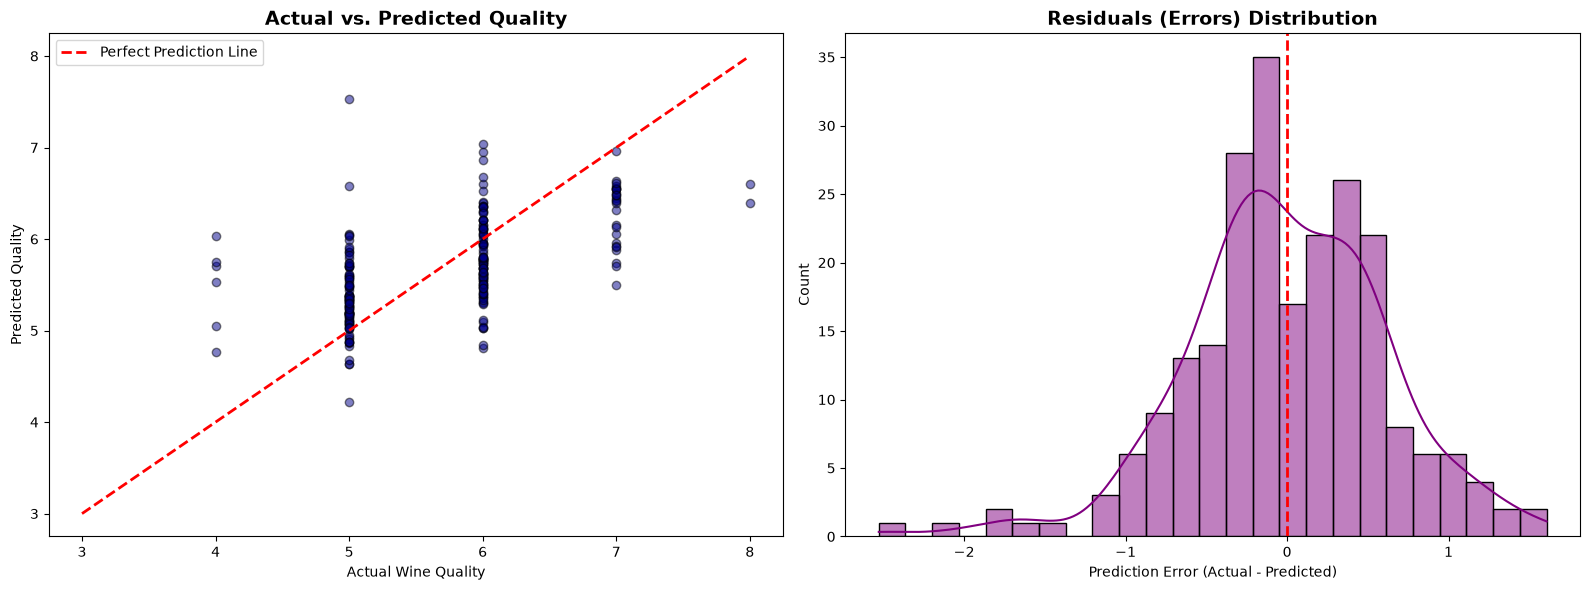

In [7]:
# 1. Calculate the 4 standard regression metrics across ALL 229 test wines
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 45)
print("     LINEAR REGRESSION EVALUATION METRICS     ")
print("=" * 45)
print(f"Mean Absolute Error (MAE):       {mae:.4f} points")
print(f"Mean Squared Error (MSE):        {mse:.4f}")
print(f"Root Mean Squared Error (RMSE):  {rmse:.4f} points")
print(f"R-squared Score (R²):            {r2:.4f} ({r2*100:.1f}%)")
print("=" * 45)

# 2. Visual Diagnostics: Actual vs Predicted & Residuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='darkblue', edgecolors='k')
axes[0].plot([3, 8], [3, 8], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
axes[0].set_title("Actual vs. Predicted Quality", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Actual Wine Quality")
axes[0].set_ylabel("Predicted Quality")
axes[0].legend()

# Plot B: Residual Plot (Error distribution)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple', bins=25, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Residuals (Errors) Distribution", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Prediction Error (Actual - Predicted)")

plt.tight_layout()
plt.show()

Base Starting Score (Intercept): 5.66 / 10
-------------------------------------------------------


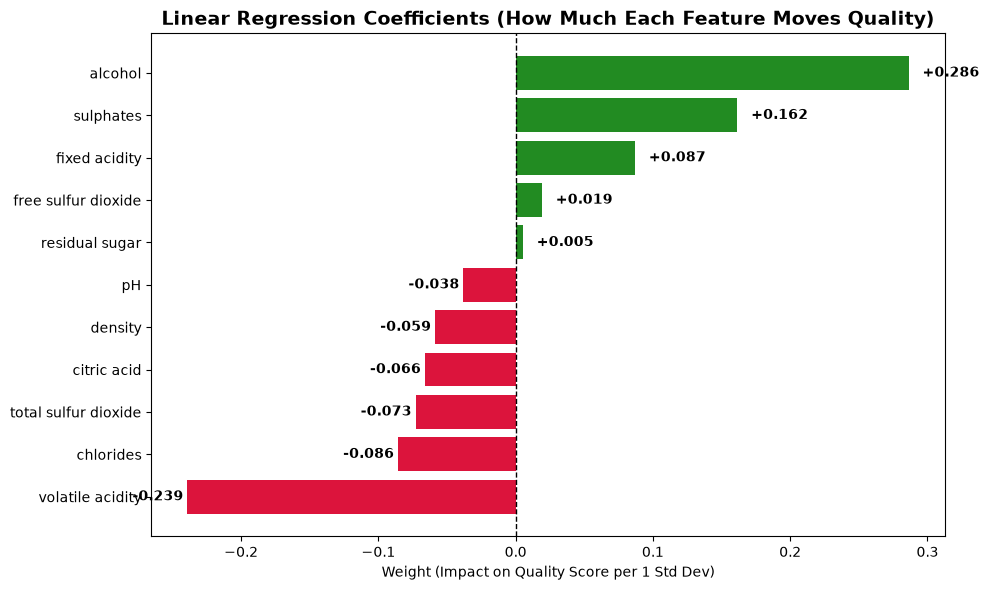

In [8]:
# 1. Extract the learned weights (coefficients) for each feature
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Weight)': model.coef_
}).sort_values(by='Coefficient (Weight)', ascending=False)

print(f"Base Starting Score (Intercept): {model.intercept_:.2f} / 10")
print("-" * 55)

# 2. Visualize: Feature Importance / Chemical Impact
plt.figure(figsize=(10, 6))
colors = ['forestgreen' if w > 0 else 'crimson' for w in coef_df['Coefficient (Weight)']]

bars = plt.barh(coef_df['Feature'], coef_df['Coefficient (Weight)'], color=colors)
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.title("Linear Regression Coefficients (How Much Each Feature Moves Quality)", fontsize=14, fontweight='bold')
plt.xlabel("Weight (Impact on Quality Score per 1 Std Dev)")
plt.gca().invert_yaxis()  # Highest positive at top

# Add exact value labels on each bar
for bar in bars:
    width = bar.get_width()
    offset = 0.01 if width >= 0 else -0.04
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, f"{width:+.3f}", 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
from sklearn.pipeline import Pipeline
import joblib

# 1. Bundle Scaling + Linear Regression into one unified Pipeline
production_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# 2. Train the pipeline on raw (unscaled) X_train
production_pipeline.fit(X_train, y_train)

# 3. Verify it gives the exact same predictions on raw X_test
test_predictions = production_pipeline.predict(X_test)
print(f"Pipeline R² Score: {r2_score(y_test, test_predictions):.4f} (Matches baseline!)")
print("-" * 55)

# 4. Export the trained pipeline to backend/app/models/
MODEL_SAVE_PATH = "../../backend/app/models/quality_model.joblib"
joblib.dump(production_pipeline, MODEL_SAVE_PATH)
print(f"Successfully exported production model artifact to:")
print(MODEL_SAVE_PATH)
print("-" * 55)

# 5. Sanity Check: Reload it from disk and simulate a single wine prediction
loaded_model = joblib.load(MODEL_SAVE_PATH)

# Simulate 1 test wine (first row of X_test)
sample_wine = X_test.iloc[[0]]
predicted_score = loaded_model.predict(sample_wine)[0]
actual_score = y_test.iloc[0]

print(f"Test Wine actual score:    {actual_score}")
print(f"Loaded model prediction:   {predicted_score:.2f} / 10")

Pipeline R² Score: 0.3171 (Matches baseline!)
-------------------------------------------------------
Successfully exported production model artifact to:
../../backend/app/models/quality_model.joblib
-------------------------------------------------------
Test Wine actual score:    5
Loaded model prediction:   5.38 / 10
